Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Las filas que cumplen el maximo son: 7, cuyas posiciones son: [  6  12  15  20  21  88 100]
Las filas que cumplen el minimo son: 4, cuyas posiciones son: [506 507 509 510]


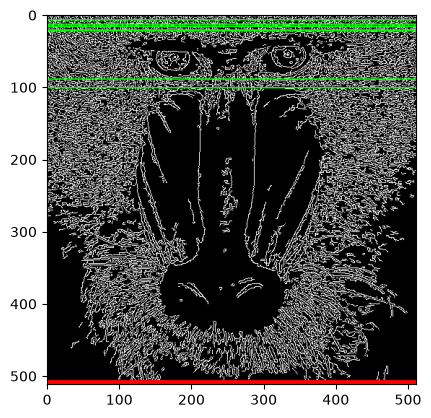

In [2]:
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
#Cuenta de pixeles blancos por filas.
#Iba a utilizar cv2.REDUCE_MAX, pero eso devuelve el brillo más alto y queremos el total de brillo de los pixeles de cada fila
filas = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Filas tiene el valor del brillo total entonces lo dividimos entre el brillo maximo(255)
pixeles_por_fila = filas/255

#Esto es como el max pero de un numpy
max_fil = np.max(pixeles_por_fila)

umbral_maximo = 0.9*max_fil
umbral_minimo = 0.1*max_fil

#Cogemos el [0] porque np.where() devuelve un tupla con la lista dentro
filas_que_cumplen_maximo = np.where(pixeles_por_fila >= umbral_maximo)[0]
filas_que_cumplen_minimo = np.where(pixeles_por_fila <= umbral_minimo)[0]

print(f"Las filas que cumplen el maximo son: {len(filas_que_cumplen_maximo)}, cuyas posiciones son: {filas_que_cumplen_maximo}")
print(f"Las filas que cumplen el minimo son: {len(filas_que_cumplen_minimo)}, cuyas posiciones son: {filas_que_cumplen_minimo}")

ancho = canny.shape[1]

#Transformamos a rgb para poder diferenciar las lineas de colores
canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
#Transformamos a pillow para poder hacer lineas
pil_image = Image.fromarray(canny_rgb) 
draw = ImageDraw.Draw(pil_image)
for i in filas_que_cumplen_maximo:
    draw.line([(0, i), (ancho - 1, i)], fill=(0, 255, 0), width=2)

for i in filas_que_cumplen_minimo:
    draw.line([(0, i), (ancho - 1, i)], fill=(255, 0, 0), width=2)

final_canny = np.array(pil_image)

plt.figure()
plt.imshow(final_canny, cmap='gray') 
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Con los bordes sobel la densidad es: 2.95, y con los bordes canny la densidad es: 0.13.


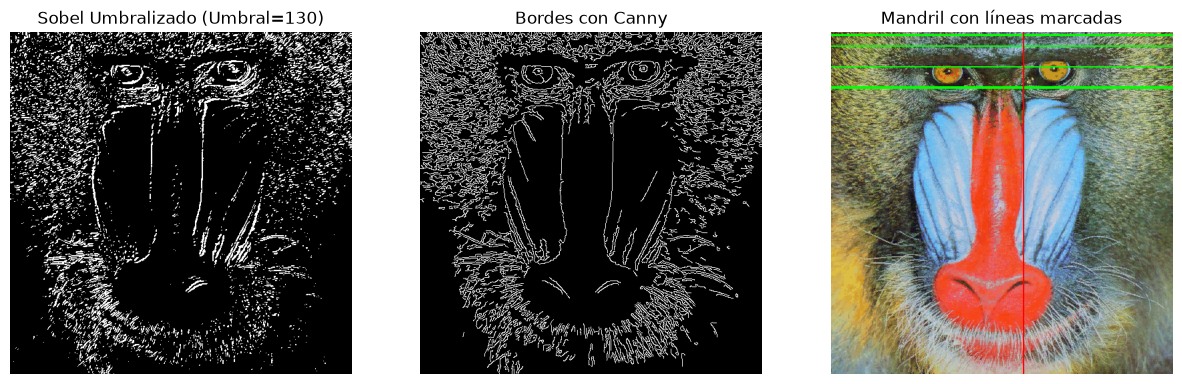

In [3]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ggris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
sobel = cv2.add(sobelx, sobely)

#Convertimos la imagen resultante de sobel a 8 bits
sobel8 = cv2.convertScaleAbs(sobel)

valorUmbral = 130 

_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

#Conteo por columnas de los pixeles no nulos con Canny
columnas = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

cols = columnas[0] / (255 * imagenUmbralizada.shape[0])

maximo_columnas = np.max(cols)

umbral_maximo_columnas = 0.9*maximo_columnas

columnas_que_cumplen_maximo = np.where(cols >= umbral_maximo_columnas)[0]

#Conteo por filas de los pixeles no nulos con Canny
filas = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Hacemos .flatten() para convertir la columna vertical de filas en un vector
rows = filas.flatten() / (255 * imagenUmbralizada.shape[1])

maximo_filas = np.max(rows)

umbral_maximo_filas = 0.9*maximo_filas

filas_que_cumplen_maximo = np.where(rows >= umbral_maximo_filas)[0]

ancho = imagenUmbralizada.shape[1]
alto = imagenUmbralizada.shape[0]

#Transformamos a pillow para poder hacer lineas
pil_image = Image.fromarray(img_rgb) 
draw = ImageDraw.Draw(pil_image)

for i in filas_que_cumplen_maximo:
    draw.line([(0, i), (ancho - 1, i)], fill=(0, 255, 0), width=2)

for i in columnas_que_cumplen_maximo:
    draw.line([(i, 0), (i, alto - 1)], fill=(255, 0, 0), width=2)

#Convertimos imagen a sobel
sobel8_resultado = np.array(pil_image)

#Convertimos la imagen a canny
canny_resultado =  cv2.Canny(ggris, 100, 200)

#Para comparar los resultados contamos los pixeles blancos de cada imagen(bordes detectados)
densidad_sobel = np.count_nonzero(sobel8_resultado) / (alto * ancho)
densidad_canny = np.count_nonzero(canny_resultado) / (alto * ancho)
print(f"Con los bordes sobel la densidad es: {round(densidad_sobel, 2)}, y con los bordes canny la densidad es: {round(densidad_canny, 2)}.")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Sobel Umbralizado (Umbral=130)")
plt.imshow(imagenUmbralizada, cmap='gray')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title("Bordes con Canny")
plt.imshow(canny_resultado, cmap='gray')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title("Mandril con líneas marcadas")
plt.imshow(sobel8_resultado)

plt.show()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [4]:
import cv2
import numpy as np
import winsound
import threading

#Estas dos funciones me ayudo la IA(ya que yo no las conocia)

#Funcion que hace sonar el beep
def sonar_nota(frecuencia, duracion=120):
    try:
        winsound.Beep(int(frecuencia), duracion)
    except:
        pass

#Funcion que hace que haya un hilo para cada mano, y además que la simulación no se congele
def reproducir_asincrono(frecuencia):
    t = threading.Thread(target=sonar_nota, args=(frecuencia,))
    t.daemon = True
    t.start()

vid = cv2.VideoCapture(0)
#Guardamos el pframe para ver la diferencia con el anterior frame(y detectar movimiento)
pframe = None
contador_frames = 0

while True:
    ret, frame = vid.read()
    
    if ret:
        #Ponemos el modo espejo para no confundirse con la perspectiva
        frame = cv2.flip(frame, 1)
        alto = frame.shape[0]
        ancho = frame.shape[1]
        mitad_x = ancho // 2
        
        #Pasamos a escala de grises y hacemos el filtro gaussiano para eliminar el ruido
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gris = cv2.GaussianBlur(gris, (15, 15), 0)
        
        #Como pframe es None lo inicializamos para comenzar a ver las diferencias
        if pframe is None:
            pframe = gris.copy()
            continue
        
        #Pasamos a escala de grises y avanzamos en los frames
        dif = cv2.absdiff(gris, pframe)
        pframe = gris.copy()
        
        #Utilizamos la función threshold para poder detectar mas facil los cambios bruscos y dilate para que sea mas facil detectarlos al ser mas anchos
        _, binaria = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
        binaria = cv2.dilate(binaria, None, iterations=2)
        
        #Dividimos las regiones en izquierda y derecha
        bin_izq = binaria[:, :mitad_x]
        bin_der = binaria[:, mitad_x:]
        
        #Calculamos el brillo de cada fila
        filas_izq = cv2.reduce(bin_izq, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() / 255
        filas_der = cv2.reduce(bin_der, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() / 255
        
        #Pintamos la linea que divide los dos segmentos y informamos un poco
        cv2.line(frame, (mitad_x, 0), (mitad_x, alto), (255, 255, 255), 2)
        cv2.putText(frame, "CANAL GRAVE (Izq)", (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, "CANAL AGUDO (Der)", (mitad_x + 30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
        
        #Variable que nos ayuda a saber cada cuanto poner el sonido
        contador_frames += 1
        
        #Ponemos 40 ya que aunque no movamos la mano puede haber ruido y algunos pixeles blancos, entonces ponemos un umbral minimo
        if np.max(filas_izq) > 40:
            #Devolvemos el lugar donde está el valor más alto(donde tenemos nuestra mano)
            fila_pico_izq = int(np.argmax(filas_izq))
            #Pintamos un circulo donde esta nuestra mano
            cv2.circle(frame, (mitad_x // 2, fila_pico_izq), 18, (0, 255, 0), -1)
            
            #Formula frecuencia y ponemos informacion del valor de esa frecuencia
            freq_izq = int(600 - (fila_pico_izq / alto) * 400)
            cv2.putText(frame, f"{freq_izq} Hz", (50, fila_pico_izq), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            #Hacemos que el ruido se ejecute cada 5 segundos
            if contador_frames % 5 == 0:
                reproducir_asincrono(freq_izq)

        #Lo mismo pero con la mano derecha
        if np.max(filas_der) > 40:
            fila_pico_der = int(np.argmax(filas_der))
            cv2.circle(frame, (mitad_x + mitad_x // 2, fila_pico_der), 18, (0, 165, 255), -1)
            
            freq_der = int(1600 - (fila_pico_der / alto) * 900)
            cv2.putText(frame, f"{freq_der} Hz", (mitad_x + 50, fila_pico_der), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)

            if contador_frames % 5 == 0:
                reproducir_asincrono(freq_der)
        
        cv2.imshow("Frecuencias con el movimiento", frame)
        cv2.imshow("Detector de movimiento", binaria)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()